In [1]:
import networkx as nx
import matplotlib.pyplot as plt

NetworkX link: https://networkx.org/documentation/stable/reference/algorithms/tree.html#module-networkx.algorithms.tree.mst 

In [2]:
G = nx.Graph()

In [3]:
weights = [('a', 'b', 4),('a', 'h', 8),('b', 'h', 11),('b', 'c', 8),('c', 'd', 7),
           ('c', 'f', 4),('c', 'i', 2),('d', 'e', 9),('d', 'f', 14),('e', 'f', 10),
           ('f', 'g',2),('g', 'h', 1),('g', 'i', 6),('h', 'i', 7)]

In [4]:
G.add_weighted_edges_from(weights)

In [5]:
G.number_of_nodes()

9

In [6]:
G.number_of_edges()

14

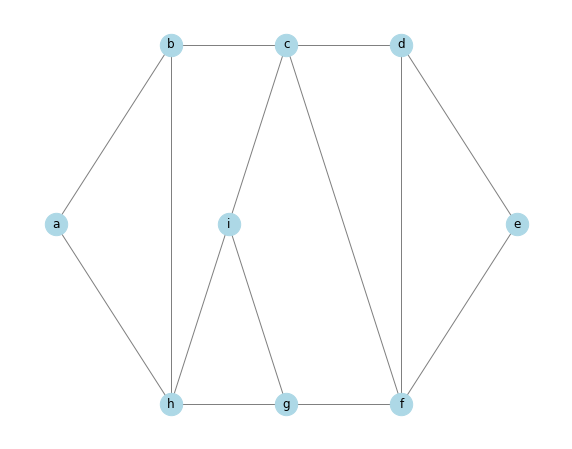

In [7]:
fixed_pos = {'a':(0,1), 'b':(1,2), 'c':(2,2), 'd':(3,2), 'e':(4,1), 'f':(3,0), 'g':(2,0), 'h':(1,0), 'i':(1.5,1)}
fixed_nodes = fixed_pos.keys()
pos = nx.spring_layout(G, pos=fixed_pos, fixed=fixed_nodes)

plt.figure(figsize=(10, 8)) 
nx.draw_networkx(G, pos=pos, edge_color="grey", node_color="lightblue", node_size=500, with_labels=True, font_size=12)
plt.axis("off")
plt.show()

In [77]:
cweight = { (i,j) : d['weight'] for i,j,d in G.edges(data=True) }
cweight

{('a', 'b'): 4,
 ('a', 'h'): 8,
 ('b', 'h'): 11,
 ('b', 'c'): 8,
 ('h', 'g'): 1,
 ('h', 'i'): 7,
 ('c', 'd'): 7,
 ('c', 'f'): 4,
 ('c', 'i'): 2,
 ('d', 'e'): 9,
 ('d', 'f'): 14,
 ('f', 'e'): 10,
 ('f', 'g'): 2,
 ('i', 'g'): 6}

In [61]:
# algoritmo de Kruskal
mst_kruskal = nx.minimum_spanning_edges(G, weight='weight', algorithm='kruskal', data=True)

In [62]:
type(mst_kruskal)

generator

In [92]:
edges_sol = [] # ET
edges_sol_dic = {} #ET com pesos
value_sol = 0
for u, v, d in mst_kruskal:
    e = tuple((u,v))
    edges_sol_dic[e] = d["weight"] 
    edges_sol.append(e)
    value_sol += d["weight"]

print(f"solution = {edges_sol_dic}")
print(f"value = {value_sol}")

solution = {('e', 'd'): 9, ('d', 'c'): 7, ('c', 'i'): 2, ('c', 'f'): 4, ('f', 'g'): 2, ('g', 'h'): 1, ('c', 'b'): 8, ('b', 'a'): 4}
value = 37


In [93]:
mst_kruskal = nx.minimum_spanning_edges(G, weight='weight', algorithm='kruskal', data=True)
weight_kruskal = sum(d['weight'] for u, v, d in mst_kruskal)
print(f"Peso total da AGM usando o algoritmo de Kruskal: {weight_kruskal}")

Peso total da AGM usando o algoritmo de Kruskal: 37


In [96]:
mst_kruskal = nx.minimum_spanning_tree(G, algorithm='kruskal')
print(f"MST Edges: {mst_kruskal.edges(data=True)}")
print(f"Total Weight: {mst_kruskal.size(weight='weight')}")

MST Edges: [('a', 'b', {'weight': 4}), ('a', 'h', {'weight': 8}), ('h', 'g', {'weight': 1}), ('c', 'i', {'weight': 2}), ('c', 'f', {'weight': 4}), ('c', 'd', {'weight': 7}), ('d', 'e', {'weight': 9}), ('f', 'g', {'weight': 2})]
Total Weight: 37.0


In [68]:
AGM = nx.DiGraph()
AGM.add_edges_from(edges_sol)

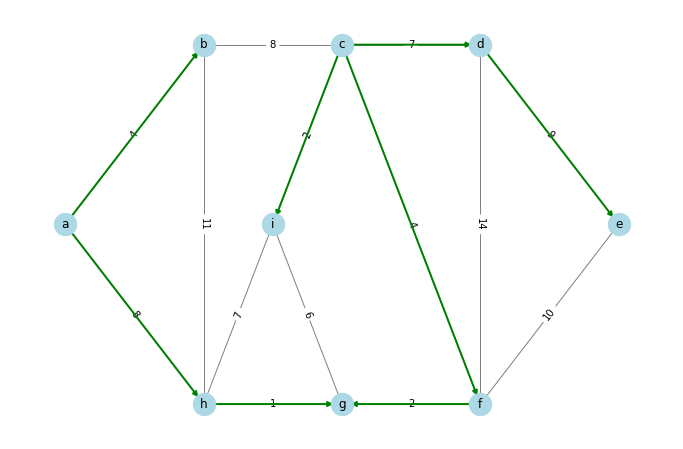

In [69]:
# Visualizando a AGM
plt.figure(figsize=(12, 8)) 
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=500)
nx.draw_networkx_edges(G, pos, edge_color="grey")
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d["weight"] for u, v, d in G.edges(data=True)})
nx.draw_networkx_edges(AGM, pos, edge_color="green", width=2)
plt.axis("off")
plt.show()

In [9]:
# algoritmo de Prim
mst_prim = nx.minimum_spanning_edges(G, weight='weight', algorithm='prim', data=True)

In [11]:
edges_sol = [] # ET
edges_sol_dic = {} #ET com pesos
value_sol = 0
for u, v, d in mst_prim:
    e = tuple((u,v))
    edges_sol_dic[e] = d["weight"] 
    edges_sol.append(e)
    value_sol += d["weight"]

print(f"solution = {edges_sol_dic}")
print(f"value = {value_sol}")

solution = {('g', 'f'): 2, ('f', 'c'): 4, ('c', 'i'): 2, ('c', 'd'): 7, ('h', 'a'): 8, ('a', 'b'): 4, ('d', 'e'): 9}
value = 36


In [88]:
mst_prim = nx.minimum_spanning_edges(G, weight='weight', algorithm='prim', data=True)
weight_prim = sum(d['weight'] for u, v, d in mst_prim)
print(f"Peso total da AGM usando o algoritmo de Prim: {weight_prim}")

Peso total da AGM usando o algoritmo de Prim: 37


In [12]:
AGM = nx.DiGraph()
AGM.add_edges_from(edges_sol)

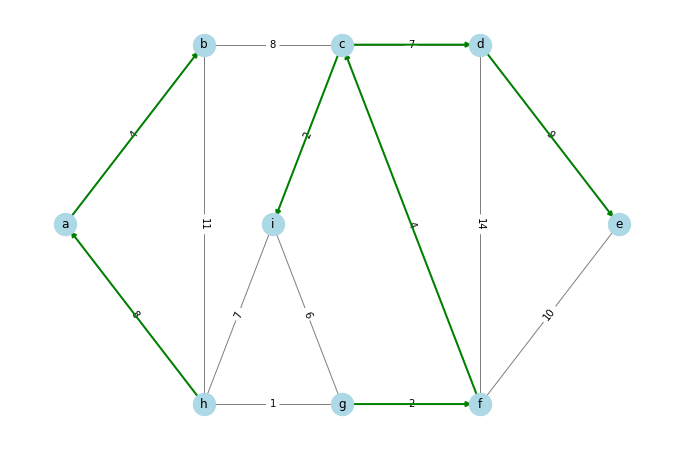

In [13]:
# Visualizando a AGM
plt.figure(figsize=(12, 8)) 
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=500)
nx.draw_networkx_edges(G, pos, edge_color="grey")
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d["weight"] for u, v, d in G.edges(data=True)})
nx.draw_networkx_edges(AGM, pos, edge_color="green", width=2)
plt.axis("off")
plt.show()